importing libraries

In [4]:
import pandas as pd              # importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Load Datasets

This section loads the two datasets required for the analysis:

1. Historical Trader Data
2. Bitcoin Fear & Greed Index

These datasets will be cleaned and merged for further analysis.

In [5]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")   #files to be read

In [6]:
print(trades.head())      # reading the files and outcomes

print(trades.info())

print(trades.describe())

print(trades.isnull().sum())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [7]:
print(sentiment.head())

print(sentiment.info())     #hidden areas to findout and cleaning

print(sentiment.isnull().sum())

    timestamp  value classification        date
0  1517463000     30           Fear  01-02-2018
1  1517549400     15   Extreme Fear  02-02-2018
2  1517635800     40           Fear  03-02-2018
3  1517722200     24   Extreme Fear  04-02-2018
4  1517808600     11   Extreme Fear  05-02-2018
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [10]:
sentiment['date'].head(10)  # analysing the type of data

0    01-02-2018
1    02-02-2018
2    03-02-2018
3    04-02-2018
4    05-02-2018
5    06-02-2018
6    07-02-2018
7    08-02-2018
8    09-02-2018
9    10-02-2018
Name: date, dtype: str

In [11]:
print(sentiment['date'].dtype)         # analysing the type of data

str


In [ ]:
%%sql


# Exploratory Data Analysis

Exploratory Data Analysis (EDA) provides an overview of the datasets before performing detailed analysis.

This section examines:

- Number of trades
- Number of unique traders
- Coins traded
- Missing values
- Basic dataset statistics

In [37]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    dayfirst=True,
    errors='coerce'
)
sentiment['Date'] = sentiment['date'].dt.date

In [38]:
df = pd.merge(
    trades,
    sentiment[['Date','classification','value']],
    on='Date',
    how='left'
)

In [39]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [40]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
classification      6
value               6
dtype: int64

In [41]:
print("Total Trades :",len(df))

Total Trades : 211224


In [42]:
print("Unique Traders :",df['Account'].nunique())

Unique Traders : 32


In [43]:
print(df['Coin'].value_counts())

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@42         1
@30         1
@135        1
@86         1
@68         1
Name: count, Length: 246, dtype: int64


In [44]:
df['Profit'] = np.where(df['Closed PnL']>0,"Profit","Loss")

In [45]:
(df['Profit']=="Profit").mean()*100

np.float64(41.12648183918494)

In [46]:
df.groupby('classification')['Closed PnL'].mean().sort_values()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64

# Trader Performance Analysis

This section evaluates trader performance using the historical trading data.

The following metrics are analyzed:

- Profit and Loss (Closed PnL)
- Top performing traders
- Worst performing traders
- Coin-wise profitability
- Monthly trading activity

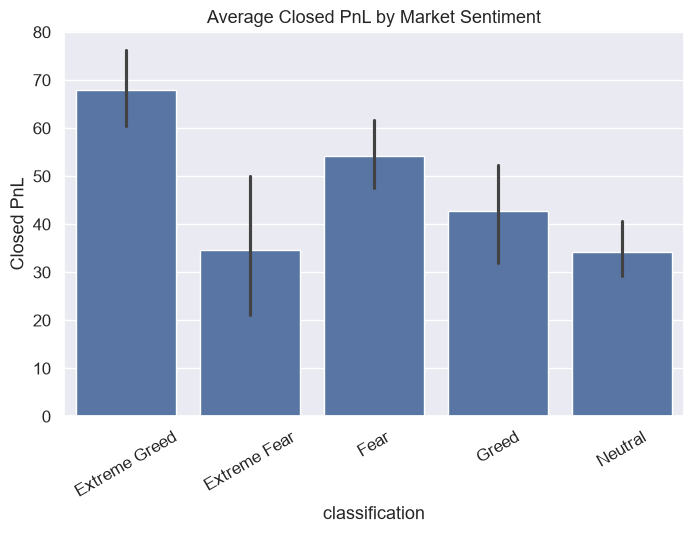

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=30)

plt.show()

In [48]:
df.groupby('classification')['Closed PnL'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

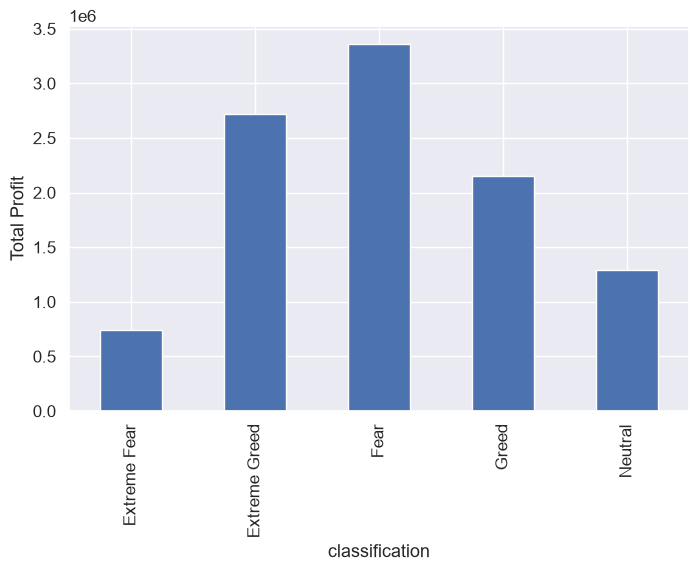

In [49]:
plt.figure(figsize=(8,5))

df.groupby('classification')['Closed PnL'].sum().plot(kind='bar')

plt.ylabel("Total Profit")

plt.show()

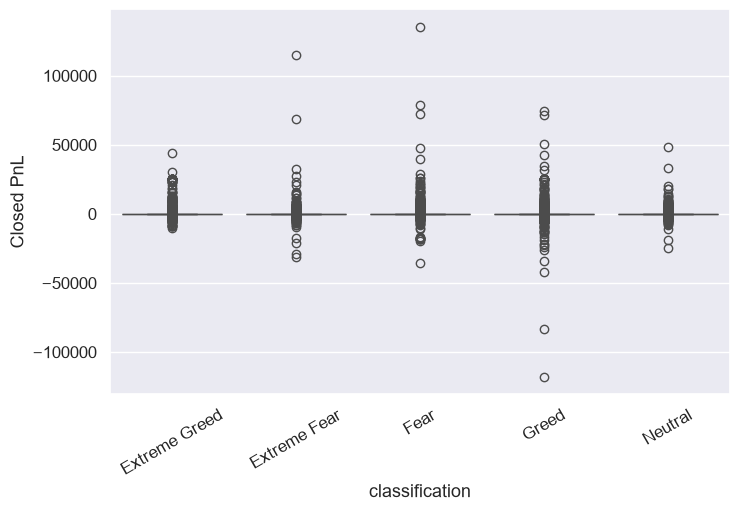

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=30)

plt.show()

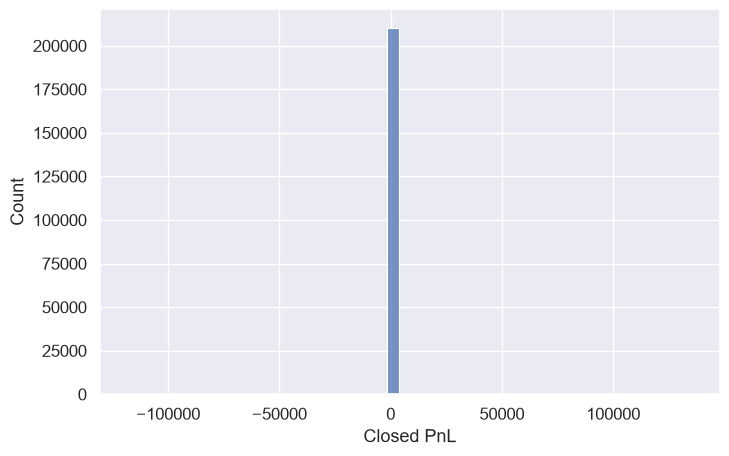

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df['Closed PnL'],bins=50)

plt.show()

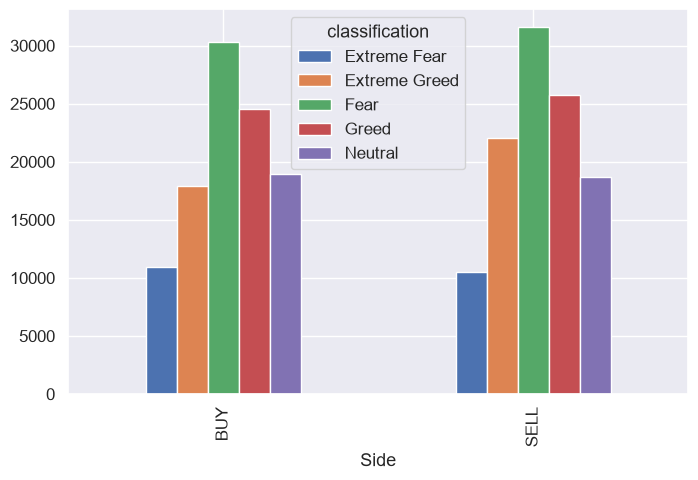

In [52]:
pd.crosstab(df['Side'],df['classification'])
pd.crosstab(df['Side'],df['classification']).plot(kind='bar',figsize=(8,5))

plt.show()

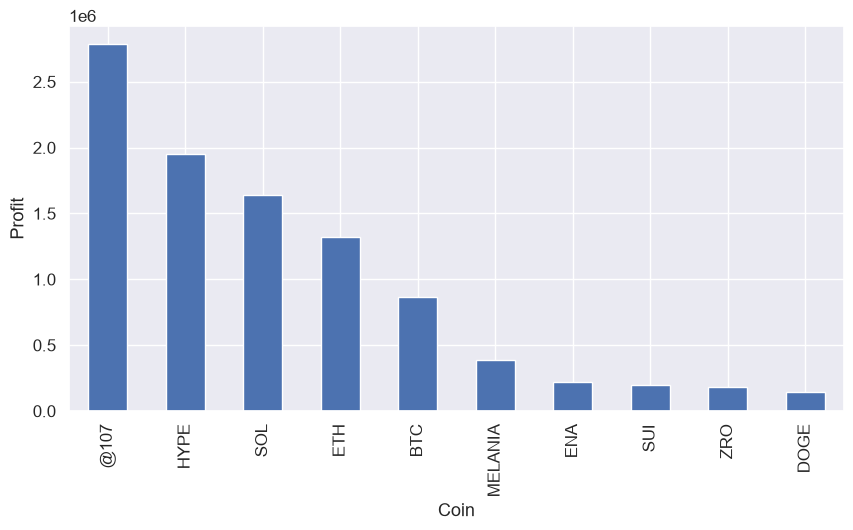

In [53]:
coin_profit = df.groupby('Coin')['Closed PnL'].sum()
coin_profit = coin_profit.sort_values(ascending=False)
coin_profit.head(10)
coin_profit.head(10).plot(
    kind='bar',
    figsize=(10,5)
)
plt.ylabel("Profit")
plt.show()


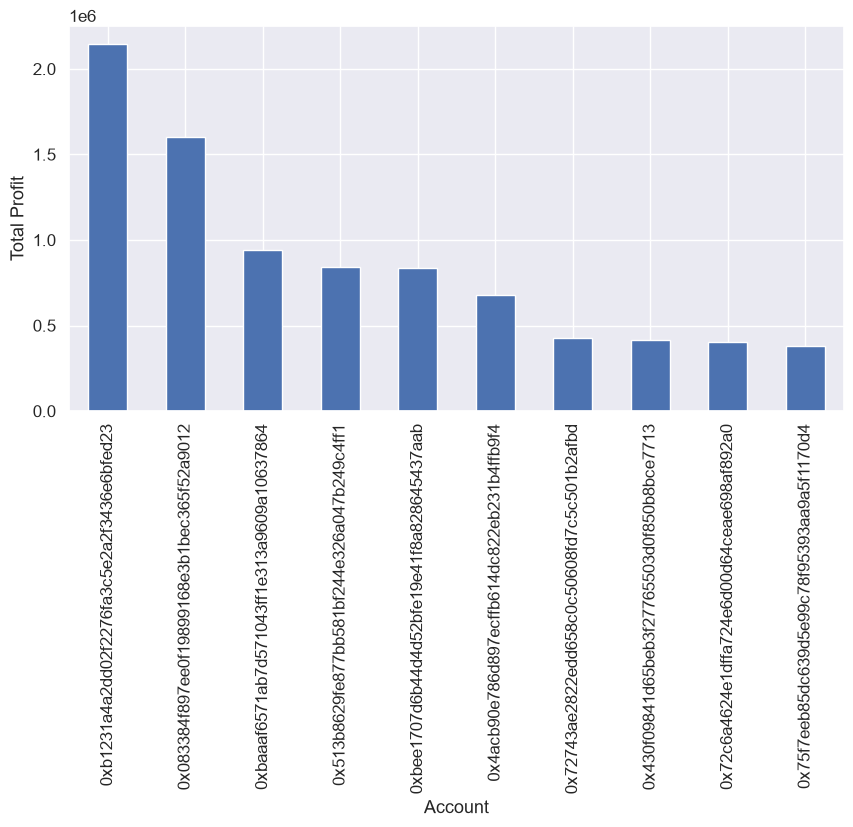

In [54]:
top_traders = df.groupby('Account')['Closed PnL'].sum()
top_traders = top_traders.sort_values(ascending=False)
top_traders.head(10)
top_traders.head(10).plot(
    kind='bar',
    figsize=(10,5)
)
plt.ylabel("Total Profit")
plt.show()

In [55]:
top_traders.tail(10)

Account
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
Name: Closed PnL, dtype: float64

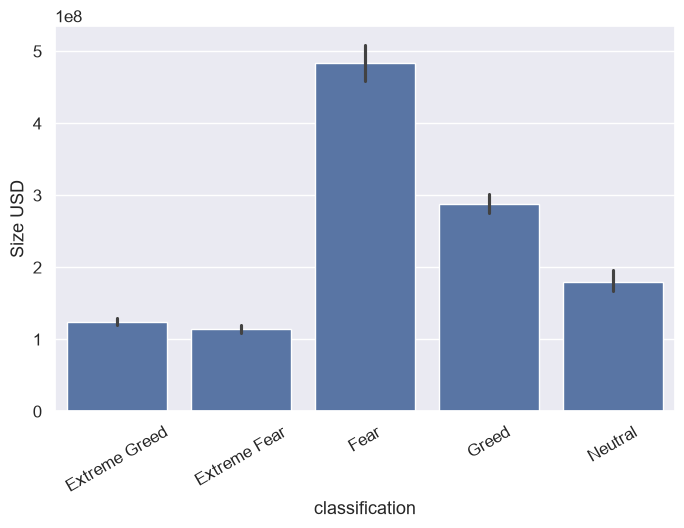

In [56]:
df.groupby('classification')['Size USD'].sum()
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='classification',
    y='Size USD',
    estimator=sum
)
plt.xticks(rotation=30)
plt.show()

In [57]:
df.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

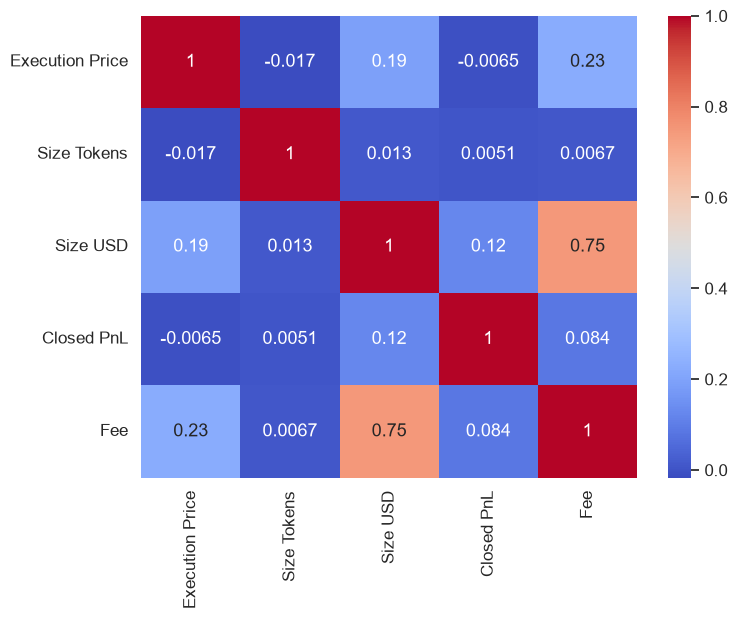

In [58]:
corr = df[['Execution Price',
           'Size Tokens',
           'Size USD',
           'Closed PnL',
           'Fee']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

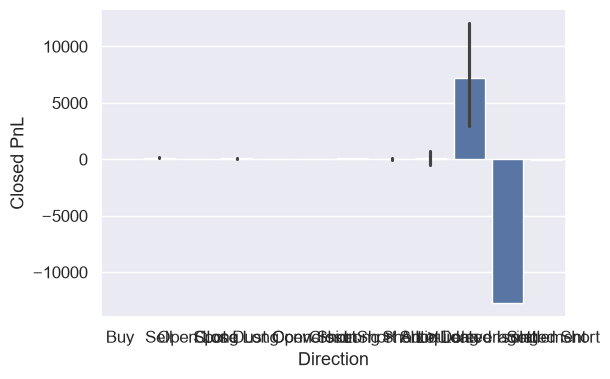

In [59]:
df.groupby('Direction')['Closed PnL'].mean()
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='Direction',
    y='Closed PnL'
)
plt.show()

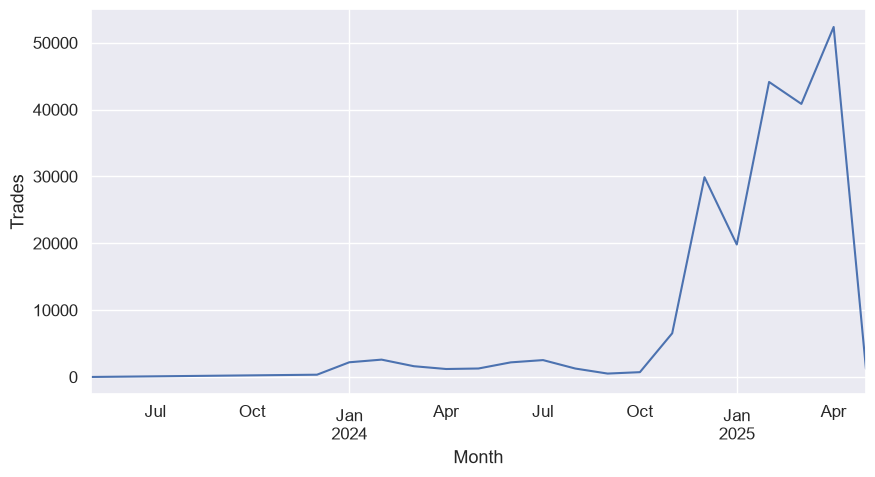

In [60]:
df.groupby('Side')['Closed PnL'].mean()
df['Month'] = df['Timestamp IST'].dt.to_period('M')

monthly = df.groupby('Month').size()

monthly.plot(figsize=(10,5))

plt.ylabel("Trades")

plt.show()

In [61]:
top_traders = df.groupby(
    ['classification', 'Account']
)['Closed PnL'].sum().reset_index()

print(top_traders.sort_values('Closed PnL', ascending=False).head(10))

    classification                                     Account    Closed PnL
62            Fear  0x083384f897ee0f19899168e3b1bec365f52a9012  1.113374e+06
59   Extreme Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  1.105305e+06
91            Fear  0xbaaaf6571ab7d571043ff1e313a9609a10637864  6.208724e+05
121          Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  5.340582e+05
61   Extreme Greed  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  4.788115e+05
109          Greed  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.535953e+05
151        Neutral  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  4.013094e+05
138        Neutral  0x513b8629fe877bb581bf244e326a047b249c4ff1  3.813305e+05
75            Fear  0x513b8629fe877bb581bf244e326a047b249c4ff1  3.671662e+05
73            Fear  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  2.967817e+05


### Average Closed PnL by Market Sentiment

This analysis compares the average profit or loss (Closed PnL) earned by traders under different Bitcoin market sentiment conditions such as Fear and Greed. It helps identify whether market sentiment has an impact on overall trading performance.

In [62]:
# Compare the average profit or loss during different market sentiments

avg_pnl = df.groupby('classification')['Closed PnL'].mean()

print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [63]:
# Calculate total profit generated under each market sentiment

total_pnl = df.groupby('classification')['Closed PnL'].sum()

print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [64]:
# Calculate the percentage of profitable trades for each sentiment

df['Win'] = df['Closed PnL'] > 0

win_rate = df.groupby('classification')['Win'].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [65]:
# Compare the average trade size across different sentiments

avg_trade_size = df.groupby('classification')['Size USD'].mean()
print(avg_trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


### Buy vs Sell Trades

This analysis compares Buy and Sell trades across different market sentiments to understand changes in trading behavior.

In [66]:
# Compare Buy and Sell trades under different market sentiments

buy_sell = pd.crosstab(df['Side'],df['classification'])
print(buy_sell)

classification  Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Side                                                              
BUY                    10935          17940  30270  24576    18969
SELL                   10465          22052  31567  25727    18717


In [67]:
# Identify the best-performing traders during different market sentiments

top_traders = df.groupby(
    ['classification','Account']
)['Closed PnL'].sum().reset_index()

top_traders = top_traders.sort_values(
    'Closed PnL',
    ascending=False
)

print(top_traders.head(10))

    classification                                     Account    Closed PnL
62            Fear  0x083384f897ee0f19899168e3b1bec365f52a9012  1.113374e+06
59   Extreme Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  1.105305e+06
91            Fear  0xbaaaf6571ab7d571043ff1e313a9609a10637864  6.208724e+05
121          Greed  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  5.340582e+05
61   Extreme Greed  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  4.788115e+05
109          Greed  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.535953e+05
151        Neutral  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  4.013094e+05
138        Neutral  0x513b8629fe877bb581bf244e326a047b249c4ff1  3.813305e+05
75            Fear  0x513b8629fe877bb581bf244e326a047b249c4ff1  3.671662e+05
73            Fear  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  2.967817e+05


In [69]:
from scipy.stats import ttest_ind
fear = df[df['classification']=='Fear']['Closed PnL']

greed = df[df['classification']=='Greed']['Closed PnL']

t_stat,p_value = ttest_ind(
    fear,
    greed,
    nan_policy='omit'
)
print("T Statistic :",t_stat)
print("P Value :",p_value)

T Statistic : 1.884727797757762
P Value : 0.05946918109970857


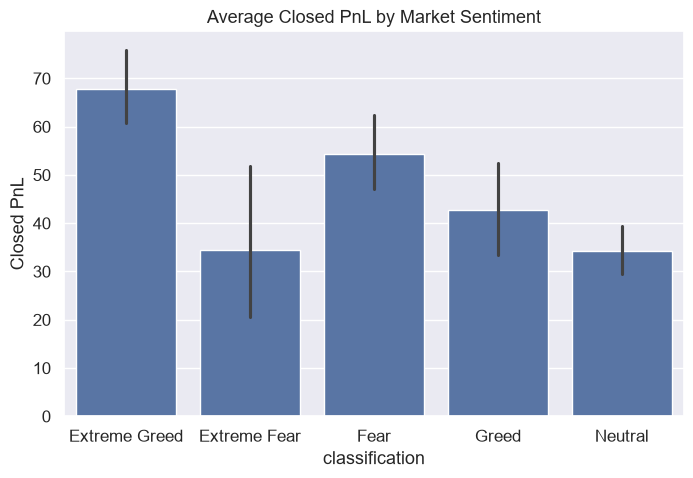

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title("Average Closed PnL by Market Sentiment")

plt.show()